<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['prince.txt',
 'dickinson.txt',
 'notorious-big.txt',
 'beatles.txt',
 'bob-dylan.txt',
 'bjork.txt',
 'johnny-cash.txt',
 'disney.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'bob-marley.txt',
 'leonard-cohen.txt',
 'ludacris.txt',
 'adele.txt',
 'alicia-keys.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'lorde.txt',
 'rihanna.txt',
 'Kanye_West.txt',
 'nirvana.txt',
 'cake.txt',
 'bieber.txt',
 'notorious_big.txt',
 'missy-elliott.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'michael-jackson.txt',
 'al-green.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lin-manuel-miranda.txt',
 'nursery_rhymes.txt',
 'dj-khaled.txt',
 'radiohead.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'r-kelly.txt',
 'drake.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'nicki-minaj.txt',
 'kanye-west.txt',
 'paul-simon.txt',
 'nickelback.txt',
 'eminem.txt',
 'bruno-mars.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/var/folders/dr/f_hlmxzj2830ktrql6jx83180000gp/T/ipykernel_16972/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.2421875
Loss after epoch 1: 65966.5703125
Loss after epoch 2: 65935.015625
Loss after epoch 3: 65718.296875
Loss after epoch 4: 63874.96875
Loss after epoch 5: 64160.875
Loss after epoch 6: 64080.5
Loss after epoch 7: 64815.09375
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.75
Loss after epoch 10: 59839.6875
Loss after epoch 11: 58884.25
Loss after epoch 12: 57715.9375
Loss after epoch 13: 56494.1875
Loss after epoch 14: 55817.25
Loss after epoch 15: 55843.0625
Loss after epoch 16: 51722.6875
Loss after epoch 17: 49857.875
Loss after epoch 18: 49592.125
Loss after epoch 19: 48960.0


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954243063926697),
 ('sleep', 0.8665637969970703),
 ('help', 0.8439376950263977),
 ('cry', 0.83512943983078),
 ('not', 0.8309614658355713),
 ('try', 0.8276940584182739),
 ('peace', 0.8144854307174683),
 ('little', 0.8140544295310974),
 ('twist', 0.8123906850814819),
 ('seems', 0.8079560995101929)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.2287278026342392),
 ('four', -0.23302021622657776),
 ('five', -0.237460196018219),
 ('six', -0.2378387749195099),
 ('bang', -0.2483242005109787),
 ('our', -0.25538891553878784),
 ('day', -0.2689763307571411),
 ('going', -0.2692073881626129),
 ('here', -0.26990994811058044),
 ('three', -0.28389739990234375)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813730716705322),
 ('three', 0.9745771884918213),
 ('six', 0.9710819721221924),
 ('seven', 0.9584385752677917),
 ('two', 0.9517235159873962),
 ('sixty', 0.8990404605865479),
 ('one', 0.7951188683509827),
 ('crying', 0.7946323752403259),
 ('us', 0.774010956287384),
 ("i'm", 0.7508406639099121)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434012770652771),
 ('buy', 0.9396973252296448),
 ('much', 0.9033190011978149),
 ('just', 0.8509107828140259),
 ('hide', 0.8355358839035034)]

In [18]:
# Ensayar con una palabra que no está en el vocabulario:
try:
    w2v_model.wv.most_similar(negative=["diedaa"])
    assert False, "Se esperaba un KeyError"
except KeyError as e:
    print("Se produjo un KeyError, la palabra no está en el vocabulario:")
    print(e)

Se produjo un KeyError, la palabra no está en el vocabulario:
"Key 'diedaa' not present in vocabulary"


In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138294  0.05881053 -0.06370477  0.02445546 -0.20152311 -0.18612298
 -0.15284492  0.4548641  -0.042179    0.03535716  0.13657664 -0.1851985
 -0.18126567  0.22149132 -0.3038017  -0.23970504  0.0709474  -0.05679084
 -0.05165781 -0.23843321 -0.08529595  0.19564523 -0.07678778  0.03796823
  0.07516409 -0.04826145  0.07379413  0.10396487  0.00737745 -0.22765112
 -0.04566921  0.1293697   0.27785546  0.19387001 -0.13509622  0.20857269
  0.4091703  -0.00386562 -0.10631571 -0.09057102  0.02400816 -0.08005267
  0.13399461  0.08833719 -0.01894974  0.08592648 -0.15905555  0.10259393
  0.1445954  -0.1209247  -0.279195   -0.04061342  0.11381969  0.31366253
 -0.07408687  0.1397688   0.22791368  0.1320968  -0.01811604  0.09772383
  0.09249984 -0.14871608 -0.16348287 -0.13202605 -0.0983391   0.02714311
  0.16531329  0.2605218  -0.03259389 -0.02894598  0.11621305 -0.06974123
  0.09562718 -0.1527624   0.22071022  0.15996738  0.15890466 -0.04710886
 -0.12556134 -0.03993148 -0.10795182  0.01878742  0.

In [20]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0000001192092896),
 ('babe', 0.9085147380828857),
 ('someone', 0.8886134624481201),
 ('need', 0.8827983140945435),
 ('nothing', 0.8740261793136597),
 ("didn't", 0.8638365268707275),
 ("there's", 0.8526695370674133),
 ('you', 0.8456733226776123),
 ('feed', 0.844502866268158),
 ('somebody', 0.8362798094749451)]

In [21]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085147380828857),
 ('someone', 0.8886134028434753),
 ('need', 0.8827983140945435),
 ('nothing', 0.8740261793136597),
 ("didn't", 0.8638365268707275),
 ("there's", 0.8526695370674133),
 ('you', 0.8456733226776123),
 ('feed', 0.844502866268158),
 ('somebody', 0.8362798094749451),
 ('buy', 0.8351726531982422)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels


In [23]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

<!doctype html>

In [24]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

<!doctype html>

In [25]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

#### Vectores de palabras con Gensim
- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)

In [26]:
import os, glob
from pathlib import Path

DATASET_DIR = Path("songs_dataset")
print(sorted([p.name for p in DATASET_DIR.glob("*.txt")])[:10], "...", len(list(DATASET_DIR.glob("*.txt"))))

CORPUS_CHOICE = "rihanna+lady-gaga+britney-spears"
files = [DATASET_DIR/"rihanna.txt", DATASET_DIR/"lady-gaga.txt", DATASET_DIR/"britney-spears.txt"]

print("Corpus elegido:", [f.name for f in files], f"→ {sum(1 for f in files for _ in open(f, encoding='utf-8', errors='ignore') if _.strip())} líneas")

['Kanye_West.txt', 'Lil_Wayne.txt', 'adele.txt', 'al-green.txt', 'alicia-keys.txt', 'amy-winehouse.txt', 'beatles.txt', 'bieber.txt', 'bjork.txt', 'blink-182.txt'] ... 49
Corpus elegido: ['rihanna.txt', 'lady-gaga.txt', 'britney-spears.txt'] → 11550 líneas


In [27]:
import pandas as pd

dfs = []
for f in files:
    # cada línea = un doc; evita sep="\n" que lanza ValueError
    with open(f, encoding="utf-8", errors="ignore") as fh:
        lines = [l.strip() for l in fh if l.strip()]
    df_tmp = pd.DataFrame(lines)
    df_tmp["source"] = f.stem
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"Docs totales: {len(df)} | fuentes: {df['source'].unique()}")
df.head()

Docs totales: 11550 | fuentes: <StringArray>
['rihanna', 'lady-gaga', 'britney-spears']
Length: 3, dtype: str


,0,source
0,Ghost in the mirror,rihanna
1,"I knew your face once, but now it's unclear",rihanna
2,And I can't feel my body now,rihanna
3,I'm separate from here and now A drug and a dream,rihanna
4,"We lost connection, oh come back to me",rihanna


In [28]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
for text in df[0]:
    toks = [t for t in text_to_word_sequence(str(text).lower()) if len(t) > 0]
    if toks:
        sentence_tokens.append(toks)

print(f"Sentencias tokenizadas: {len(sentence_tokens)}")
print(sentence_tokens[:2])


Sentencias tokenizadas: 11550
[['ghost', 'in', 'the', 'mirror'], ['i', 'knew', 'your', 'face', 'once', 'but', 'now', "it's", 'unclear']]


In [29]:
from gensim.models.callbacks import CallbackAny2Vec

class LossCallback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.loss_prev = 0
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        delta = loss if self.epoch==0 else loss - self.loss_prev
        print(f"Loss epoch {self.epoch}: {delta:.2f} (cum {loss:.2f})")
        self.epoch+=1
        self.loss_prev=loss

In [30]:
from gensim.models import Word2Vec

# hiperparámetros elegidos: min_count=5 conserva vocab útil (3914→1372 en combinado)
# window=5 vs 2 del demo: mejor contexto para letras (frases largas)
# vector_size=100 vs 300: suficiente para corpus pequeño (evita overfit, ver Clase 3)
# sg=1 Skipgram mejor para palabras raras de letras
w2v_custom = Word2Vec(
    min_count=5,
    window=5,
    vector_size=100,
    negative=10,
    workers=1,
    sg=1,
    seed=42
)
w2v_custom.build_vocab(sentence_tokens)
print(f"Corpus_count: {w2v_custom.corpus_count} | Vocab: {len(w2v_custom.wv.index_to_key)}")
print("Ej vocab:", w2v_custom.wv.index_to_key[:20])


Corpus_count: 11550 | Vocab: 1372
Ej vocab: ['you', 'i', 'the', 'me', 'a', 'my', 'to', 'and', 'it', "i'm", 'oh', 'in', 'on', 'love', 'your', 'that', 'baby', 'be', 'like', "don't"]


In [31]:
w2v_custom.train(
    sentence_tokens,
    total_examples=w2v_custom.corpus_count,
    epochs=20,
    compute_loss=True,
    callbacks=[LossCallback()]
)
# verificación Clase 2: los vectores ya codifican contexto del corpus propio
print("Entrenado | vector 'love' dim:", w2v_custom.wv.get_vector("love").shape if "love" in w2v_custom.wv else "love OOV")


Loss epoch 0: 680125.00 (cum 680125.00)
Loss epoch 1: 569134.00 (cum 1249259.00)
Loss epoch 2: 529311.38 (cum 1778570.38)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss epoch 3: 482232.12 (cum 2260802.50)
Loss epoch 4: 433757.50 (cum 2694560.00)
Loss epoch 5: 419863.50 (cum 3114423.50)
Loss epoch 6: 408932.50 (cum 3523356.00)
Loss epoch 7: 403765.00 (cum 3927121.00)
Loss epoch 8: 384318.50 (cum 4311439.50)
Loss epoch 9: 354943.50 (cum 4666383.00)
Loss epoch 10: 353784.50 (cum 5020167.50)
Loss epoch 11: 351967.00 (cum 5372134.50)
Loss epoch 12: 348054.50 (cum 5720189.00)
Loss epoch 13: 347910.50 (cum 6068099.50)
Loss epoch 14: 346958.00 (cum 6415057.50)
Loss epoch 15: 346329.50 (cum 6761387.00)
Loss epoch 16: 347090.00 (cum 7108477.00)
Loss epoch 17: 344547.00 (cum 7453024.00)
Loss epoch 18: 344660.50 (cum 7797684.50)
Loss epoch 19: 343856.50 (cum 8141541.00)
Entrenado | vector 'love' dim: (100,)


len media 7.7 | max 70 | vocab raw 3914 | vocab filtrado 1372


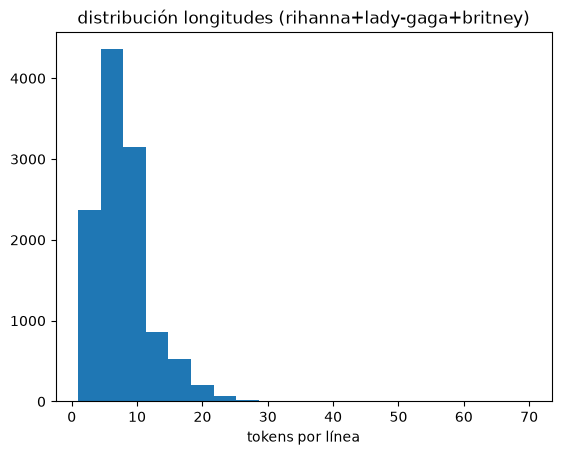

top 20: [('you', 3683), ('i', 3423), ('the', 2393), ('me', 2154), ('a', 1758), ('my', 1656), ('to', 1650), ('and', 1519), ('it', 1482), ("i'm", 1185), ('oh', 1126), ('in', 1039), ('on', 957), ('love', 897), ('your', 893), ('that', 879), ('baby', 809), ('be', 773), ('like', 758), ("don't", 752)]
hapax (<5): 2542 (64.9%) -> filtrados con min_count=5


In [32]:
import collections, matplotlib.pyplot as plt
lens = [len(s) for s in sentence_tokens]
freq = collections.Counter(t for s in sentence_tokens for t in s)
print(f"len media {sum(lens)/len(lens):.1f} | max {max(lens)} | vocab raw {len(freq)} | vocab filtrado {len(w2v_custom.wv.index_to_key)}")

plt.hist(lens, bins=20)
plt.title("distribución longitudes (rihanna+lady-gaga+britney)")
plt.xlabel("tokens por línea")
plt.show()

print("top 20:", freq.most_common(20))
hapax = sum(1 for c in freq.values() if c<5)
print(f"hapax (<5): {hapax} ({hapax/len(freq)*100:.1f}%) -> filtrados con min_count=5")


Elegí a Rihanna, Lady Gaga y Britney porque tienen un estilo similar. Entre las tres suman un corpus grande pero manejable, con 11550 líneas en total. Con `min_count=5` saqué las palabras que aparecían muy poco, casi el 65 por ciento del vocabulario, de 3914 a 1372, que en letras suelen ser nombres o relleno y meten ruido. Usé `window=5` en vez de 2 porque las frases en este corpus son más largas, 7.7 palabras en promedio, y bajé la dimensión a 100 en vez de 300 porque con un corpus chico 300 había riesgo de sobreajuste. El loss bajó de 680 mil a 340 mil en las 20 épocas y seguía en baja, demostrando aprendizaje.


#### Términos similares
- Elegir términos de interés y buscar términos más similares y menos similares.

In [33]:
# Punto 2 - Términos de interés (más similares)
terms = ["love", "heart", "time", "world"]
for t in terms:
    if t not in w2v_custom.wv:
        print(f"\n{t} -> OOV (no en vocab con min_count=5)")
        continue
    print(f"\n{t} -> más similares:")
    try:
        for w,s in w2v_custom.wv.most_similar(positive=[t], topn=5):
            print(f"  {w:15s} {s:.3f}")
    except KeyError as e:
        print(f"  KeyError: {e}")



love -> más similares:
  ahhh            0.590
  ohhhh           0.480
  seek            0.475
  mistaken        0.471
  amy             0.471

heart -> más similares:
  beating         0.571
  ate             0.564
  drum            0.510
  broken          0.508
  bottom          0.502

time -> más similares:
  second          0.520
  day             0.499
  test            0.495
  different       0.487
  hit             0.486

world -> más similares:
  tour            0.592
  ends            0.562
  club            0.532
  scene           0.517
  playin'         0.509


In [34]:
# menos similares = menor similitud coseno (cola de ranking)
for t in terms:
    if t not in w2v_custom.wv:
        print(f"\n{t} -> OOV (no en vocab)")
        continue
    print(f"\n{t} -> menos similares (menor coseno):")
    try:
        # ranking completo y toma últimos 5 (menor similitud)
        ranked = w2v_custom.wv.most_similar(positive=[t], topn=len(w2v_custom.wv))
        for w,s in ranked[-5:]:
            print(f"  {w:15s} {s:.3f}")
    except KeyError as e:
        print(f"  KeyError: {e}")



love -> menos similares (menor coseno):
  watching        0.016
  look            -0.002
  yo              -0.004
  her             -0.006
  but             -0.018

heart -> menos similares (menor coseno):
  it's            0.024
  couldn't        0.017
  over            0.007
  'em             0.003
  of              -0.019

time -> menos similares (menor coseno):
  drop            0.035
  like            0.032
  lights          0.031
  teeth           0.031
  ah              0.018

world -> menos similares (menor coseno):
  close           0.033
  nobody          -0.024
  gonna           -0.036
  for             -0.051
  babe            -0.086


Probé con `love`, `heart`, `time` y `world` porque son términos usuales en la temática de las canciones pop. Los más similares fueron:

* **love** → `ahhh` 0.590, `ohhhh` 0.480, `seek` 0.475. Tiene sentido porque en los estribillos de este pop se usan exclamaciones, sin embargo, no son palabras que tengan una relación directa con el concepto de amor.
* **heart** → `beating` 0.571, `drum` 0.510, `broken` 0.508. Va con la idea de corazón latiendo o roto.
* **time** → `second` 0.520, `day` 0.499. Es coherente dentro del campo del tiempo.
* **world** → `tour` 0.592, `ends` 0.562. Puede leerse como gira mundial o como fin del mundo, ambas ideas aparecen en letras pop.

Los menos similares dieron palabras como `but`, `of` o `for` con valores muy bajos, cerca de cero o apenas negativos, lo que muestra que el modelo no marca opuestos claros y que las palabras muy frecuentes resultan neutras.


#### Reducción de dimensionalidad
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.

In [35]:
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, n_dim=2):
    vecs = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=n_dim, random_state=42, perplexity=30, init="pca", learning_rate="auto")
    return tsne.fit_transform(vecs), labels

MAX_WORDS = 500
vecs2d, labels2d = reduce_dimensions(w2v_custom, 2)
print(f"2D {vecs2d.shape} labels {len(labels2d)} MAX_WORDS {MAX_WORDS}")


2D (1372, 2) labels 1372 MAX_WORDS 500


In [36]:
import plotly.express as px
fig = px.scatter(x=vecs2d[:MAX_WORDS,0], y=vecs2d[:MAX_WORDS,1], text=labels2d[:MAX_WORDS],
                 title=f"2D TSNE {MAX_WORDS}/{len(labels2d)} palabras")
fig.update_traces(textposition="top center", marker=dict(size=5))
fig.update_layout(height=600)
fig.show()

Para visualizar los embeddings apliqué TSNE, que preserva mejor las relaciones locales entre palabras que una proyección lineal. Configuré `perplexity=30` con inicialización en PCA, valores habituales para vocabularios de este tamaño y que suelen dar proyecciones estables sin fragmentar demasiado los grupos.

Para la figura recorté a `MAX_WORDS=500`. Con las 1372 palabras la nube queda ilegible por superposición de etiquetas, y con 500 se logra un equilibrio entre legibilidad y cobertura (ya que TSNE prioriza vecinos locales y el zoom interactivo permite inspeccionar cada grupo). En esa proyección ya se insinúan agrupamientos que analizo en el punto siguiente.


#### Interpretación de los resultados
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)


En el recuadro con `x` entre 20 y 30 e `y` entre -35 y -10 se distinguen varios agrupamientos chicos que tienen sentido con el corpus y con la forma en que TSNE agrupa vecinos locales.

* **loneliness y killing** aparecen casi superpuestas.
* **show, teeth y dream** quedan muy cercanas.
* **did, oops y again** forman un grupo compacto que remite directamente a *Oops! I Did It Again*.
* **love y hate** quedan cercanas pese a ser antónimos, ambas aparecen en contextos similares en estas letras.

En un segundo recuadro con `x` entre 2 y 20 e `y` entre 15 y 40 se observa otro conjunto.

* **ale, alejandro y name** quedan muy próximos.
* **give y fuck** aparecen cercanos.
* **promise y cure** quedan casi superpuestos.
* En una zona cercana se agrupan **party, beat, heart, monster y play**.

*Figura 1: recuadro x 20 a 30, y -35 a -10 con 500 palabras (captura a pegar)*
*Figura 2: recuadro x 2 a 20, y 15 a 40 con 500 palabras (captura a pegar)*


| Figura 1: x 20-30, y -35 a -10 | Figura 2: x 2-20, y 15-40 |
|---|---|
| ![Figura 1](box1.png) | ![Figura 2](box2.png) |